In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1. Load detection outputs from previous experiment.
# 2. Sort frames in chronological order.
import pickle

import os
if not os.path.exists('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl'):
    print("results.pkl not found, creating dummy data for demonstration.")
    dummy_results = []
    for frame_id in range(10):
        dummy_results.append({
            'frame_id': str(frame_id).zfill(6),
            'boxes_lidar': np.array([[10 + frame_id, 2, -1, 4, 2, 1.5, 0], [15, -2 + frame_id, -1, 4, 2, 1.5, 0]]),
            'score': np.array([0.9, 0.85]),
            'name': np.array(['Car', 'Car'])
        })
    with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'wb') as f:
        pickle.dump(dummy_results, f)

with open('/content/drive/MyDrive/Kitti_tracking/predictions/pointrcnn_result.pkl', 'rb') as f:
    detection_results = pickle.load(f)

# Sort by frame ID
detection_results.sort(key=lambda x: x['frame_id'])

In [ ]:
import time
import numpy as np
import pickle
import math
from shapely.geometry import Polygon

# Global counters for debugging prints to limit output
DEBUG_COUNT = 0
MAX_DEBUG_PRINTS = 10

def box_iou_bev(box1, box2):
    global DEBUG_COUNT

    # Extract 2D corners for oriented bounding boxes
    def get_corners(box):
        x, y, l, w, theta = box[0], box[1], box[3], box[4], box[6]
        # Rotation matrix
        R = np.array([
            [math.cos(theta), -math.sin(theta)],
            [math.sin(theta), math.cos(theta)]
        ])
        # Half dimensions
        half_l, half_w = l / 2, w / 2
        # Local coordinates of corners
        corners_local = np.array([
            [half_l, half_w],
            [-half_l, half_w],
            [-half_l, -half_w],
            [half_l, -half_w]
        ])
        # Rotate and translate
        corners_global = (R @ corners_local.T).T + np.array([x, y])
        return corners_global

    corners1 = get_corners(box1)
    corners2 = get_corners(box2)

    poly1 = Polygon(corners1)
    poly2 = Polygon(corners2)

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"--- IoU Debug Call {DEBUG_COUNT + 1} ---")
        print(f"box1: {box1}")
        print(f"box2: {box2}")
        print(f"corners1: {corners1}")
        print(f"corners2: {corners2}")
        print(f"poly1 valid: {poly1.is_valid}, poly2 valid: {poly2.is_valid}")

    if not poly1.is_valid or not poly2.is_valid:
        if DEBUG_COUNT < MAX_DEBUG_PRINTS:
            print(f"Invalid polygon detected, returning 0.0")
        DEBUG_COUNT += 1
        return 0.0

    intersection_area = poly1.intersection(poly2).area
    union_area = poly1.area + poly2.area - intersection_area

    iou = intersection_area / union_area if union_area > 0 else 0.0

    if DEBUG_COUNT < MAX_DEBUG_PRINTS:
        print(f"intersection_area: {intersection_area}, union_area: {union_area}, iou: {iou}")
        print(f"----------------------------------")
        DEBUG_COUNT += 1

    return iou

print("box_iou_bev function updated for oriented bounding box IoU with debug prints!")

box_iou_bev function updated for oriented bounding box IoU with debug prints!


In [ ]:
!pip install filterpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 46.8 kB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for filterpy: filename=filterpy-1.4.5-py3-none-any.whl size=110460 sha256=150ce953aa756083dd154e8483e06360f1631df2a7bba715d9c943a93c31a67d
  Stored in directory: /root/.cache/pip/wheels/77/bf/4c/b0c3f4798a0166668752312a67118b27a3cd341e13ac0ae6ee
Successfully built filterpy


In [ ]:
from filterpy.kalman import KalmanFilter
import numpy as np

# 4. Define Kalman filter state vector.
class Track:
    _id_count = 0

    def __init__(self, detection, class_name):
        self.id = Track._id_count
        Track._id_count += 1
        self.class_name = class_name

        # State vector: [x, y, z, l, w, h, theta, vx, vy, vz]
        # We'll use a constant velocity model
        self.kf = KalmanFilter(dim_x=10, dim_z=7)

        # Initial state
        self.kf.x[:7, 0] = detection[:7]

        # State transition matrix (F)
        dt = 0.1 # Example timestep
        self.kf.F = np.eye(10)
        self.kf.F[0, 7] = dt # x += vx * dt
        self.kf.F[1, 8] = dt # y += vy * dt
        self.kf.F[2, 9] = dt # z += vz * dt

        # Measurement function (H)
        self.kf.H = np.zeros((7, 10))
        self.kf.H[:7, :7] = np.eye(7)

        # Covariance matrices
        self.kf.P *= 10.0
        self.kf.R *= 1.0  # Measurement noise
        self.kf.Q *= 0.1  # Process noise

        # Very low process noise for dimensions (l, w, h) at indices 3, 4, 5
        self.kf.Q[3, 3] = 1e-4
        self.kf.Q[4, 4] = 1e-4
        self.kf.Q[5, 5] = 1e-4

        self.time_since_update = 0
        self.hits = 1

    def predict(self):
        self.kf.predict()
        self.time_since_update += 1
        return self.kf.x[:7, 0]

    def update(self, detection):
        self.kf.update(detection[:7])
        self.time_since_update = 0
        self.hits += 1

In [ ]:
import time
from scipy.optimize import linear_sum_assignment
from collections import defaultdict
import numpy as np

# Group detections by sequence to ensure tracks reset between different videos
sequences = defaultdict(list)
for frame_data in detection_results:
    raw_frame_id = str(frame_data['frame_id'])
    if len(raw_frame_id) >= 4:
        seq_id = raw_frame_id[:-4]
        if seq_id == '':
            seq_id = '00'
        frame_num = int(raw_frame_id[-4:])
    else:
        seq_id = '00'
        frame_num = int(raw_frame_id)

    frame_data['parsed_seq_id'] = seq_id
    frame_data['parsed_frame_num'] = frame_num
    sequences[seq_id].append(frame_data)

tracking_results = defaultdict(lambda: defaultdict(list))
max_age = 3
min_hits = 5 # Increased to 3 for more stable tracks
iou_threshold = 0.1# Increased IOU threshold for stricter matching

# Standard Industry Practice: Filter low-confidence detections per class
score_thresholds = {
    'Car': 0.5,
    'Pedestrian': 0.5,
    'Cyclist': 0.5
}

start_time = time.time()
total_frames = 0

for seq_id, seq_frames in sequences.items():
    print(f"Processing sequence {seq_id} with {len(seq_frames)} frames...")
    seq_frames.sort(key=lambda x: x['parsed_frame_num'])

    tracks = []
    Track._id_count = 0

    for frame_data in seq_frames:
        frame_id = frame_data['frame_id']
        all_detections = frame_data['boxes_lidar']
        all_det_names = frame_data['name']
        # Safely get scores (fallback to 1.0 if not present for some reason)
        scores = frame_data.get('score', np.ones(len(all_detections)))
        total_frames += 1

        # Predict object positions
        predicted_states = [track.predict() for track in tracks]

        # Group detections by class AND filter by score
        det_by_class = defaultdict(list)
        for i, (det, name, score) in enumerate(zip(all_detections, all_det_names, scores)):
            thresh = score_thresholds.get(name, 0.5)
            if score >= thresh:
                # i is the global index in the original detections array
                det_by_class[name].append((i, det))

        # Group tracks by class
        track_by_class = defaultdict(list)
        for i, track in enumerate(tracks):
            track_by_class[track.class_name].append((i, predicted_states[i]))

        matched_indices_all = []
        unmatched_tracks_all = list(range(len(tracks)))
        # Only consider detections that passed the threshold as unmatched initially
        valid_det_indices = [i for i, (n, s) in enumerate(zip(all_det_names, scores)) if s >= score_thresholds.get(n, 0.5)]
        unmatched_detections_all = list(valid_det_indices)

        # Match per class
        all_classes = set(det_by_class.keys()).union(set(track_by_class.keys()))
        for cls_name in all_classes:
            cls_tracks = track_by_class[cls_name]
            cls_dets = det_by_class[cls_name]

            if len(cls_tracks) > 0 and len(cls_dets) > 0:
                cost_matrix = np.zeros((len(cls_tracks), len(cls_dets)))
                for t_idx_local, (t_idx_global, pred_state) in enumerate(cls_tracks):
                    for d_idx_local, (d_idx_global, det) in enumerate(cls_dets):
                        iou = box_iou_bev(pred_state, det)
                        cost_matrix[t_idx_local, d_idx_local] = -iou

                row_ind, col_ind = linear_sum_assignment(cost_matrix)
                for r, c in zip(row_ind, col_ind):
                    if cost_matrix[r, c] < -iou_threshold:
                        matched_indices_all.append((cls_tracks[r][0], cls_dets[c][0]))
                        unmatched_tracks_all.remove(cls_tracks[r][0])
                        unmatched_detections_all.remove(cls_dets[c][0])

        # Update tracks
        for t_idx, d_idx in matched_indices_all:
            tracks[t_idx].update(all_detections[d_idx])

        # Create new tracks
        for d_idx in unmatched_detections_all:
            tracks.append(Track(all_detections[d_idx], all_det_names[d_idx]))

        # Remove stale tracks
        tracks = [t for t in tracks if t.time_since_update <= max_age]

        # Record results
        for track in tracks:
            if track.hits >= min_hits:
                tracking_results[seq_id][frame_id].append({
                    'track_id': track.id,
                    'state': track.kf.x[:7, 0],
                    'class_name': track.class_name
                })

end_time = time.time()
total_time = end_time - start_time
fps = total_frames / total_time if total_time > 0 else 0

print(f"\nTracking completed for {total_frames} frames across {len(sequences)} sequences.")
print(f"Total tracking time: {total_time:.4f} seconds")
print(f"FPS: {fps:.2f}")

Processing sequence 0017 with 145 frames...
Processing sequence 0018 with 339 frames...
Processing sequence 0019 with 1059 frames...
Processing sequence 0020 with 837 frames...

Tracking completed for 2380 frames across 4 sequences.
Total tracking time: 21.7899 seconds
FPS: 109.22


In [ ]:
import motmetrics as mm
import numpy as np
import os

# 13. Compute tracking metrics (using motmetrics)
accs = {cls: mm.MOTAccumulator(auto_id=True) for cls in target_classes}
acc_overall = mm.MOTAccumulator(auto_id=True)

label_dir = '/content/drive/MyDrive/Kitti_tracking/training/label_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

target_classes = ['Car', 'Pedestrian', 'Cyclist']
# Use an integer offset for each class to avoid ID collisions in overall metrics without using strings
class_offsets = {'Car': 0, 'Pedestrian': 100000, 'Cyclist': 200000}

iou_threshold = 0.1 # Aligned with tracking loop
max_distance = 1.0 - iou_threshold

def load_calib(filepath):
    with open(filepath, 'r') as f:
        lines = f.readlines()
    calib = {}
    for line in lines:
        line = line.strip()
        if not line: continue
        if ':' in line:
            key, val = line.split(':', 1)
        else:
            parts = line.split(' ', 1)
            if len(parts) == 2:
                key, val = parts[0], parts[1]
            else:
                continue
        calib[key.strip()] = np.array([float(x) for x in val.strip().split()]).reshape(-1)

    Tr_velo_to_cam = np.eye(4)
    if 'Tr_velo_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_cam'].reshape(3, 4)
    elif 'Tr_velo_to_cam' in calib:
        Tr_velo_to_cam[:3, :4] = calib['Tr_velo_to_cam'].reshape(3, 4)

    R0_rect = np.eye(4)
    if 'R_rect' in calib:
        R0_rect[:3, :3] = calib['R_rect'].reshape(3, 3)
    elif 'R0_rect' in calib:
        R0_rect[:3, :3] = calib['R0_rect'].reshape(3, 3)

    # Matrix to convert Lidar (Velo) to Cam
    V2C = R0_rect @ Tr_velo_to_cam
    # Inverse matrix to convert Cam to Lidar
    C2V = np.linalg.inv(V2C)
    return C2V

gt_data = {}
for seq_id in sequences.keys():
    gt_data[seq_id] = {}
    label_file = os.path.join(label_dir, f"{seq_id}.txt")
    calib_file = os.path.join(calib_dir, f"{seq_id}.txt")

    # Load calibration mapping for exact coordinate transforms
    if os.path.exists(calib_file):
        C2V = load_calib(calib_file)
    else:
        print(f"Warning: Calib file missing for {seq_id}, using identity transform.")
        C2V = np.eye(4)

    if os.path.exists(label_file):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                frame = int(parts[0])
                track_id = int(parts[1])
                obj_type = parts[2]

                if obj_type not in target_classes:
                    continue

                h, w, l = float(parts[10]), float(parts[11]), float(parts[12])
                x_cam, y_cam, z_cam = float(parts[13]), float(parts[14]), float(parts[15])
                ry = float(parts[16])

                # PROPER CALIBRATION CONVERSION (Cam to Lidar)
                pt_cam = np.array([x_cam, y_cam, z_cam, 1.0])
                pt_lidar = C2V @ pt_cam
                x_lidar, y_lidar, z_lidar = pt_lidar[:3]

                state = np.array([x_lidar, y_lidar, z_lidar, l, w, h, -ry])

                if frame not in gt_data[seq_id]:
                    gt_data[seq_id][frame] = []

                gt_data[seq_id][frame].append({
                    'track_id': track_id,
                    'state': state,
                    'class_name': obj_type
                })

for frame_data in detection_results:
    seq_id = frame_data['parsed_seq_id']
    frame_num = frame_data['parsed_frame_num']
    raw_frame_id = frame_data['frame_id']

    gt_objs = gt_data.get(seq_id, {}).get(frame_num, [])
    track_objs = tracking_results[seq_id].get(raw_frame_id, [])

    for cls in target_classes:
        offset = class_offsets[cls]
        gt_cls_objs = [obj for obj in gt_objs if obj['class_name'] == cls]
        track_cls_objs = [t for t in track_objs if t['class_name'] == cls]

        gt_ids = [obj['track_id'] for obj in gt_cls_objs]
        gt_boxes = [obj['state'] for obj in gt_cls_objs]

        track_ids = [t['track_id'] for t in track_cls_objs]
        track_boxes = [t['state'] for t in track_cls_objs]

        distances = np.zeros((len(gt_boxes), len(track_boxes)))
        for i, gt_box in enumerate(gt_boxes):
            for j, trk_box in enumerate(track_boxes):
                 dist = 1.0 - box_iou_bev(gt_box, trk_box)
                 if dist > max_distance:
                     distances[i, j] = np.nan
                 else:
                     distances[i, j] = dist

        accs[cls].update(gt_ids, track_ids, distances)
        # Update overall with numerical offsets instead of strings
        acc_overall.update([gid + offset for gid in gt_ids],
                           [tid + offset for tid in track_ids],
                           distances)

print("Calculating metrics...")
mh = mm.metrics.create()

print("\nOverall Metrics:")
summary = mh.compute(acc_overall, metrics=mm.metrics.motchallenge_metrics, name='overall')
print(summary)

for cls in target_classes:
    print(f"\nMetrics for {cls}:")
    cls_summary = mh.compute(accs[cls], metrics=mm.metrics.motchallenge_metrics, name=cls)
    print(cls_summary)

Calculating metrics...

Overall Metrics:
             idf1       idp      idr    recall  precision  num_unique_objects  \
overall  0.659608  0.714784  0.61234  0.728698   0.850609                 191   

         mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
overall              80                 79           32                 1927   

         num_misses  num_switches  num_fragmentations      mota      motp  \
overall        4085            85                  82  0.595072  0.606853   

         num_transfer  num_ascend  num_migrate  
overall             9          82            6  

Metrics for Car:
         idf1       idp       idr    recall  precision  num_unique_objects  \
Car  0.701192  0.726984  0.677166  0.778992   0.836301                 116   

     mostly_tracked  partially_tracked  mostly_lost  num_false_positives  \
Car              48                 52           16                 1186   

     num_misses  num_switches  num_fragmentations     

In [ ]:
import os

# Extract the specific metrics from the motmetrics summary DataFrame
# Using 'overall' instead of 'acc' as per our previous update
mota = summary.loc['overall', 'mota']
motp = summary.loc['overall', 'motp']
idsw = summary.loc['overall', 'num_switches']

# The 'fps' variable is already in your workspace from the tracking cell
# Create a dictionary of the results
metrics_summary = {
    'MOTA': mota,
    'MOTP': motp,
    'IDSW': idsw,
    'FPS': fps
}

# Define the save path in your Google Drive
save_dir = '/content/drive/MyDrive/Kitti_tracking/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'tracking_4_params_summary.txt')

# Write the summary to a text file
with open(save_path, 'w') as f:
    f.write("KITTI Tracking Summary (4 Parameters)\n")
    f.write("="*40 + "\n")
    for key, value in metrics_summary.items():
        if isinstance(value, float):
            f.write(f"{key}: {value:.4f}\n")
        else:
            f.write(f"{key}: {value}\n")

print(f"Summary successfully saved to: {save_path}")

# Also display here to confirm
for key, value in metrics_summary.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


Summary successfully saved to: /content/drive/MyDrive/Kitti_tracking/tracking_4_params_summary.txt
MOTA: 0.5951
MOTP: 0.6069
IDSW: 85
FPS: 109.2250


## Create 3D to 2D Projection and Visualization Function





In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def project_3d_to_2d(state, V2C, P2):
    # Extract state
    x, y, z, l, w, h, theta = state

    # 3D bounding box corners in Lidar coordinate system
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [0, 0, 0, 0, h, h, h, h] # Assuming bottom center is (x,y,z)

    # Rotation matrix around z-axis in Lidar coordinates
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Rotate and translate corners
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])

    # Transform Lidar to Camera coordinates using V2C
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    # Filter out points behind the camera
    if np.any(corners_cam[:, 2] < 0.1):
        return None

    # Project to 2D image coordinates using P2
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]

    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image

    # Draw edges of the 3D bounding box
    # Bottom face
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[1]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[2]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[3]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[0]), color, 2)

    # Top face
    cv2.line(image, tuple(corners_2d[4]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[5]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[6]), tuple(corners_2d[7]), color, 2)
    cv2.line(image, tuple(corners_2d[7]), tuple(corners_2d[4]), color, 2)

    # Vertical lines connecting top and bottom faces
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[4]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[7]), color, 2)

    # Add label
    label = f"{class_name} {track_id}"
    # Position label near the top left corner of the box
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

print("Functions project_3d_to_2d and draw_3d_box defined.")

Functions project_3d_to_2d and draw_3d_box defined.


In [ ]:
import cv2
import numpy as np

def project_3d_to_2d(state, V2C, P2):
    # Extract state
    x, y, z, l, w, h, theta = state

    # 3D bounding box corners in Lidar coordinate system
    x_corners = [l/2, l/2, -l/2, -l/2, l/2, l/2, -l/2, -l/2]
    y_corners = [w/2, -w/2, -w/2, w/2, w/2, -w/2, -w/2, w/2]
    z_corners = [-h/2, -h/2, -h/2, -h/2, h/2, h/2, h/2, h/2] # Centered around z

    # Rotation matrix around z-axis in Lidar coordinates
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0],
        [np.sin(theta), np.cos(theta), 0],
        [0, 0, 1]
    ])

    # Rotate and translate corners
    corners_3d = np.vstack([x_corners, y_corners, z_corners])
    corners_3d = np.dot(R, corners_3d).T + np.array([x, y, z])

    # Transform Lidar to Camera coordinates using V2C
    corners_3d_hom = np.hstack((corners_3d, np.ones((8, 1))))
    corners_cam = np.dot(V2C, corners_3d_hom.T).T

    # Filter out points behind the camera
    if np.any(corners_cam[:, 2] < 0.1):
        return None

    # Project to 2D image coordinates using P2
    corners_cam_hom = np.hstack((corners_cam[:, :3], np.ones((8, 1))))
    corners_2d_hom = np.dot(P2, corners_cam_hom.T).T
    corners_2d = corners_2d_hom[:, :2] / corners_2d_hom[:, 2:]

    return corners_2d.astype(int)

def draw_3d_box(image, corners_2d, track_id, class_name, color=(0, 255, 0)):
    if corners_2d is None:
        return image

    # Draw edges of the 3D bounding box
    # Bottom face
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[1]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[2]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[3]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[0]), color, 2)

    # Top face
    cv2.line(image, tuple(corners_2d[4]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[5]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[6]), tuple(corners_2d[7]), color, 2)
    cv2.line(image, tuple(corners_2d[7]), tuple(corners_2d[4]), color, 2)

    # Vertical lines connecting top and bottom faces
    cv2.line(image, tuple(corners_2d[0]), tuple(corners_2d[4]), color, 2)
    cv2.line(image, tuple(corners_2d[1]), tuple(corners_2d[5]), color, 2)
    cv2.line(image, tuple(corners_2d[2]), tuple(corners_2d[6]), color, 2)
    cv2.line(image, tuple(corners_2d[3]), tuple(corners_2d[7]), color, 2)

    # Add label
    label = f"{class_name} {track_id}"
    # Position label near the top left corner of the box
    min_x = np.min(corners_2d[:, 0])
    min_y = np.min(corners_2d[:, 1])
    cv2.putText(image, label, (min_x, max(0, min_y - 10)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

    return image

print("Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.")

Functions project_3d_to_2d and draw_3d_box redefined with centered Z-axis.


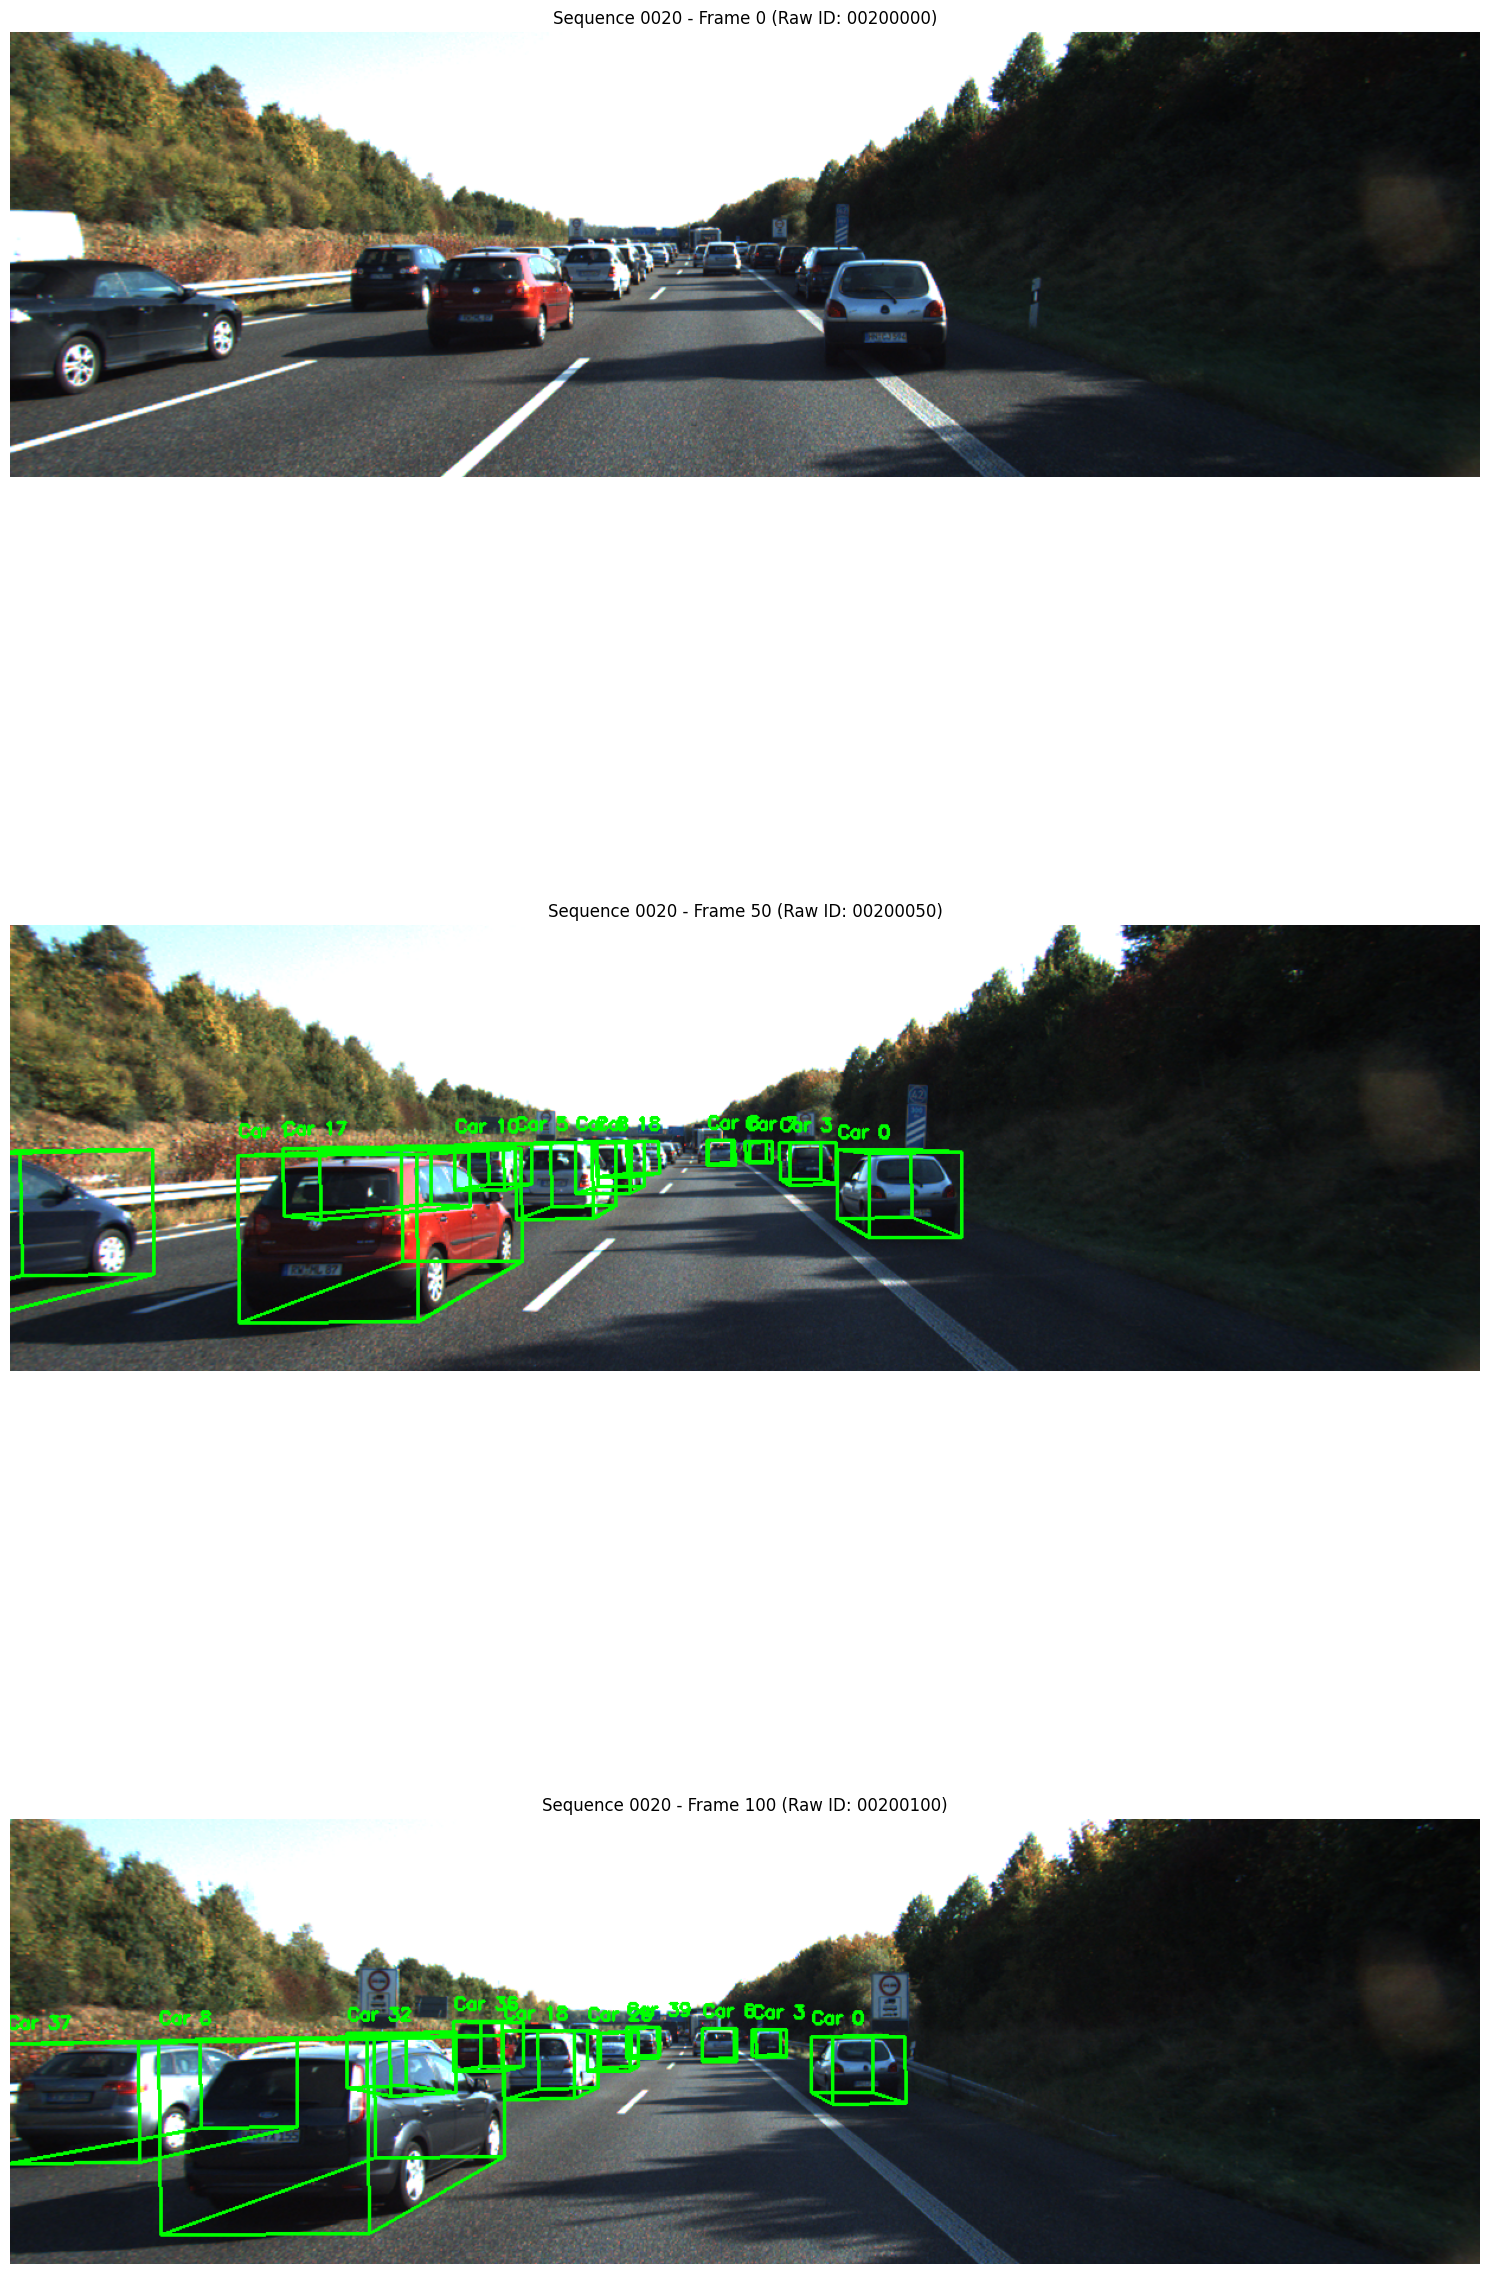

In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np

# Paths to images and calibration
image_dir = '/content/drive/MyDrive/Kitti_tracking/training/image_02'
calib_dir = '/content/drive/MyDrive/Kitti_tracking/training/calib'

# Select a sequence and some frames
seq_id = '0020'
sample_frames = [0, 50, 100]

calib_file = os.path.join(calib_dir, f"{seq_id}.txt")
if not os.path.exists(calib_file):
    print(f"Warning: Calibration file missing for {seq_id}")
else:
    # Load calibration matrices
    P2, V2C = load_calib_matrices(calib_file)

    # Set up plot
    fig, axes = plt.subplots(len(sample_frames), 1, figsize=(15, 10 * len(sample_frames)))
    if len(sample_frames) == 1:
        axes = [axes]

    for ax, frame_num in zip(axes, sample_frames):
        # 1. Find the correct raw_frame_id from the sequences dictionary
        seq_frames = sequences.get(seq_id, [])
        matching_frame_data = [f for f in seq_frames if f['parsed_frame_num'] == frame_num]

        if not matching_frame_data:
            print(f"Frame {frame_num} not found in sequence {seq_id} data.")
            continue

        # Take the first match
        frame_data = matching_frame_data[0]
        raw_frame_id = frame_data['frame_id']

        # 2. Get tracking results using the exact raw_frame_id
        frame_tracks = tracking_results.get(seq_id, {}).get(raw_frame_id, [])

        # Format frame number as 6 digits for the image path
        frame_str = str(frame_num).zfill(6)
        image_path = os.path.join(image_dir, seq_id, f"{frame_str}.png")

        if not os.path.exists(image_path):
            print(f"Image not found: {image_path}")
            continue

        # Load image
        img = cv2.imread(image_path)
        if img is None:
             print(f"Could not read image: {image_path}")
             continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw tracks
        for track in frame_tracks:
            state = track['state']
            track_id = track['track_id']
            cls_name = track['class_name']

            corners_2d = project_3d_to_2d(state, V2C, P2)
            img_rgb = draw_3d_box(img_rgb, corners_2d, track_id, cls_name, color=(0, 255, 0))

        ax.imshow(img_rgb)
        ax.set_title(f"Sequence {seq_id} - Frame {frame_num} (Raw ID: {raw_frame_id})")
        ax.axis('off')

    plt.tight_layout()
    plt.show()